# Sionna RT Scenario Visualization

This notebook visualizes all scenarios defined in `heatmap_situations.py`, showing:
- Building positions and geometry
- Transmitter location (red)
- RIS points (blue)
- Receiver locations (green)
- Propagation paths (rays) between actors

Each scenario is loaded from its corresponding XML file in `mesh_scene/` and rendered with Sionna RT.

## Setup and Imports

In [11]:
import os
import numpy as np
import pandas as pd
from IPython.display import display

# Import Sionna RT components
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver, mi

# Import situation definitions
from heatmap_situations import situations
from heatmap_utils import line_intersects_building
from sionna_utils import Actor, calculate_orientation, calculate_ris_orientation

navigable_preview = False

print("✓ Imports successful")

✓ Imports successful


## Visualization Function

In [12]:
def visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256):
    """
    Visualize a single scenario with buildings, actors, and propagation paths.
    
    This version shows paths from:
    - TX → RIS points
    - TX → Receivers
    - RIS → other RIS points (if visible)
    - RIS → Receivers
    
    Paths crossing buildings are automatically filtered out.
    
    Args:
        situation: Situation dictionary from heatmap_situations.py
        render_resolution: Tuple of (width, height) for rendered image
        num_samples: Number of samples for ray tracing (higher = better quality)
    """
    simulation_name = situation['simulation_name']
    scene_path = f"mesh_scene/{simulation_name}.xml"
    
    if not os.path.exists(scene_path):
        print(f"❌ Error: Scene file not found: {scene_path}")
        return
    
    print(f"\n{'='*60}")
    print(f"{simulation_name}")
    print(f"{'='*60}")
    print(f"Scene: {situation['width']}m × {situation['height']}m | "
          f"Buildings: {len(situation['buildings'])} | "
          f"RIS: {len(situation['ris_points'])} | "
          f"Receivers: {len(situation['receivers'])}")
    
    # Load scene
    scene = load_scene(scene_path)
    scene.frequency = 3.5e9
    
    # Configure antenna arrays (simple isotropic for visualization)
    scene.tx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    # Create Actor objects for path computation
    tx_point = situation['transmitter']
    ris_points = situation['ris_points']
    receivers = situation['receivers']
    buildings = situation['buildings']
    
    print(f"\n🔍 DEBUG: Starting path collection...")
    print(f"  TX point: {tx_point}")
    print(f"  RIS points (P1, P2, ...): {ris_points}")
    print(f"  Receivers (R1, R2, ...): {receivers}")
    
    # Helper function to check if path should be rendered
    def should_render_path(from_point, to_point, from_label, to_label):
        """Check if path between two points should be rendered."""
        # Skip Receiver → Receiver paths (R1, R2, etc.)
        if from_label.startswith('R') and to_label.startswith('R'):
            print(f"  ⊗ Skipping {from_label} → {to_label} (receiver to receiver)")
            return False
        
        # Skip if path crosses a building
        if line_intersects_building(buildings, from_point, to_point):
            print(f"  ⊗ Skipping {from_label} → {to_label} (building intersection)")
            return False
        
        print(f"  ✓ Including {from_label} → {to_label}")
        return True
    
    # Collect all paths to compute
    paths_to_compute = []
    
    print(f"\n📍 Collecting TX → P and TX → R paths...")
    # TX → all RIS (P1, P2, ...) and Receivers (R1, R2, ...)
    for i, ris_point in enumerate(ris_points):
        if should_render_path(tx_point, ris_point, 'TX', f'P{i+1}'):
            paths_to_compute.append(('TX', tx_point, f'P{i+1}', ris_point))
    
    for i, receiver in enumerate(receivers):
        if should_render_path(tx_point, receiver, 'TX', f'R{i+1}'):
            paths_to_compute.append(('TX', tx_point, f'R{i+1}', receiver))
    
    print(f"\n📍 Collecting P → P and P → R paths...")
    # RIS → all other RIS and Receivers
    for i, ris_from in enumerate(ris_points):
        # P → other P
        for j, ris_to in enumerate(ris_points):
            if i != j and should_render_path(ris_from, ris_to, f'P{i+1}', f'P{j+1}'):
                paths_to_compute.append((f'P{i+1}', ris_from, f'P{j+1}', ris_to))
        
        # P → R
        for j, receiver in enumerate(receivers):
            if should_render_path(ris_from, receiver, f'P{i+1}', f'R{j+1}'):
                paths_to_compute.append((f'P{i+1}', ris_from, f'R{j+1}', receiver))
    
    print(f"\n✅ Total paths to compute: {len(paths_to_compute)}")
    for src_label, src_point, dst_label, dst_point in paths_to_compute:
        print(f"  • {src_label} → {dst_label}")
    
    # Add visual markers (not for path computation)
    # Transmitter (RED)
    tx = Transmitter(
        name="TX_visual",
        position=mi.Point3f([tx_point['x'], tx_point['y'], 1.5]),
        orientation=mi.Point3f([0.0, 0.0, 0.0]),
        display_radius=0.5,
        color=[1.0, 0.0, 0.0]  # Red
    )
    scene.add(tx)
    
    # RIS Points (BLUE) - labeled as P1, P2, ...
    for i, ris_point in enumerate(ris_points):
        ris = Receiver(
            name=f"P{i+1}_visual",
            position=mi.Point3f([ris_point['x'], ris_point['y'], 1.5]),
            orientation=mi.Point3f([0.0, 0.0, 0.0]),
            display_radius=0.4,
            color=[0.0, 0.0, 1.0]  # Blue
        )
        scene.add(ris)
    
    # Receivers (GREEN) - labeled as R1, R2, ...
    for i, receiver in enumerate(receivers):
        rx = Receiver(
            name=f"R{i+1}_visual",
            position=mi.Point3f([receiver['x'], receiver['y'], 1.5]),
            orientation=mi.Point3f([0.0, 0.0, 0.0]),
            display_radius=0.3,
            color=[0.0, 1.0, 0.0]  # Green
        )
        scene.add(rx)
    
    # Setup camera position
    center_x = situation['width'] / 2
    center_y = situation['height'] / 2
    max_dim = max(situation['width'], situation['height'])

    camera_height = max_dim * 2
    camera_offset = max_dim * 0.15
    look_at_height = 5.0

    camera = Camera(
        position=mi.Point3f([center_x - camera_offset, center_y - camera_offset, camera_height]),
        look_at=mi.Point3f([center_x, center_y, look_at_height])
    )
    
    # Compute propagation paths
    # Strategy: Run PathSolver for each unique source
    all_paths = []
    
    try:
        # Group paths by source
        print(f"\n🔄 Grouping paths by source...")
        source_groups = {}
        for src_label, src_point, dst_label, dst_point in paths_to_compute:
            if src_label not in source_groups:
                source_groups[src_label] = []
            source_groups[src_label].append((dst_label, dst_point))
        
        print(f"✅ Grouped into {len(source_groups)} source(s):")
        for src_label, destinations in source_groups.items():
            print(f"  • {src_label} → {len(destinations)} destination(s): {[d[0] for d in destinations]}")
        
        path_solver = PathSolver()
        
        for src_idx, (src_label, destinations) in enumerate(source_groups.items(), 1):
            print(f"\n🔄 [{src_idx}/{len(source_groups)}] Computing paths from {src_label}...")
            
            # Determine source point
            if src_label == 'TX':
                src_point = tx_point
            else:
                # P1, P2, etc.
                ris_idx = int(src_label.replace('P', '')) - 1
                src_point = ris_points[ris_idx]
            
            print(f"  Source position: {src_point}")
            
            # Add source as transmitter
            tx_temp = Transmitter(
                name=f"temp_tx_{src_label}",
                position=mi.Point3f([src_point['x'], src_point['y'], 1.5]),
                orientation=mi.Point3f([0.0, 0.0, 0.0])
            )
            scene.add(tx_temp)
            print(f"  ✓ Added temp transmitter: temp_tx_{src_label}")
            
            # Add all destinations as receivers
            rx_temps = []
            for dst_label, dst_point in destinations:
                rx_temp = Receiver(
                    name=f"temp_rx_{dst_label}",
                    position=mi.Point3f([dst_point['x'], dst_point['y'], 1.5]),
                    orientation=mi.Point3f([0.0, 0.0, 0.0])
                )
                scene.add(rx_temp)
                rx_temps.append((dst_label, rx_temp))
                print(f"  ✓ Added temp receiver: temp_rx_{dst_label} at {dst_point}")
            
            # Compute paths
            print(f"  🔄 Running PathSolver...")
            paths = path_solver(
                scene=scene,
                max_depth=3,
                los=True,
                specular_reflection=True,
                diffuse_reflection=False,
                refraction=True,
                synthetic_array=True,
                seed=42
            )
            
            print(f"  ✅ PathSolver completed for {src_label}")
            print(f"     Paths object type: {type(paths)}")
            
            all_paths.append(paths)
            
            # Clean up temporary objects
            scene.remove(f"temp_tx_{src_label}")
            for dst_label, _ in rx_temps:
                scene.remove(f"temp_rx_{dst_label}")
            print(f"  ✓ Cleaned up temporary objects")
        
        print(f"\n✅ Computed paths from {len(source_groups)} sources")
        print(f"   Total path objects collected: {len(all_paths)}")
        
        # Render scene with all paths
        print(f"\n🎨 Rendering scene...")
        print(f"   Paths to render: {len(all_paths)} path object(s)")
        
        if not navigable_preview:
            # Try rendering with list of paths
            if len(all_paths) > 1:
                print(f"   ⚠️ WARNING: Attempting to render {len(all_paths)} separate path objects")
                print(f"   Sionna may only support rendering a single Paths object!")
                print(f"   If you don't see all paths, this is likely the issue.")
            
            scene.render(
                camera=camera,
                paths=all_paths if len(all_paths) > 1 else all_paths[0] if all_paths else None,
                resolution=render_resolution,
                num_samples=num_samples,
                clip_at=max(30, camera_height * 1.5)
            )
        else:
            scene.preview()
        
        print(f"✅ Complete\n")
        
    except Exception as e:
        print(f"❌ ERROR computing paths: {e}")
        import traceback
        traceback.print_exc()
        print("\nRendering without paths...")
        
        # Render without paths
        if not navigable_preview:
            scene.render(
                camera=camera,
                resolution=render_resolution,
                num_samples=num_samples,
                clip_at=max(30, camera_height * 1.5)
            )
        else:
            scene.preview()
        
        print(f"✓ Complete\n")

print("✓ Visualization function loaded")

✓ Visualization function loaded


## Visualize All Scenarios

The following cell will visualize each scenario in the situations list.

**Color Legend:**
- 🔴 **Red sphere** = Transmitter (TX)
- 🔵 **Blue spheres** = RIS Points (RIS1, RIS2, ...)
- 🟢 **Green spheres** = Receivers (RX1, RX2, ...)
- **Colored rays** = Propagation paths

SCENARIO VISUALIZATION

Found 5 scenarios to visualize


[1/5]

Single Reflection
Scene: 20m × 20m | Buildings: 2 | RIS: 1 | Receivers: 2

🔍 DEBUG: Starting path collection...
  TX point: {'x': 3, 'y': 3}
  RIS points (P1, P2, ...): [{'x': 7, 'y': 9}]
  Receivers (R1, R2, ...): [{'x': 16, 'y': 11}, {'x': 10, 'y': 18}]

📍 Collecting TX → P and TX → R paths...
  ✓ Including TX → P1
  ⊗ Skipping TX → R1 (building intersection)
  ⊗ Skipping TX → R2 (building intersection)

📍 Collecting P → P and P → R paths...
  ✓ Including P1 → R1
  ✓ Including P1 → R2

✅ Total paths to compute: 3
  • TX → P1
  • P1 → R1
  • P1 → R2

🔄 Grouping paths by source...
✅ Grouped into 2 source(s):
  • TX → 1 destination(s): ['P1']
  • P1 → 2 destination(s): ['R1', 'R2']

🔄 [1/2] Computing paths from TX...
  Source position: {'x': 3, 'y': 3}
  ✓ Added temp transmitter: temp_tx_TX
  ✓ Added temp receiver: temp_rx_P1 at {'x': 7, 'y': 9}
  🔄 Running PathSolver...
  ✅ PathSolver completed for TX
     Paths object typ

Traceback (most recent call last):
  File "/tmp/ipykernel_349695/2242460096.py", line 251, in visualize_scenario
    scene.render(
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/scene.py", line 626, in render
    image = render(
            ^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 173, in render
    overlay_scene = get_overlay_scene(
                    ^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 396, in get_overlay_scene
    starts, ends, colors = paths_to_segments(paths)
                           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/utils/render.py", line 165, in paths_to_segments
    vertices = paths.vertices.numpy()
               ^^^^^^^^^^^^^^
AttributeError: 'list' object has no attribute 'vertices'


✓ Complete


[2/5]

Single Reflection BIG
Scene: 2000m × 2000m | Buildings: 2 | RIS: 1 | Receivers: 2

🔍 DEBUG: Starting path collection...
  TX point: {'x': 300, 'y': 300}
  RIS points (P1, P2, ...): [{'x': 700, 'y': 900}]
  Receivers (R1, R2, ...): [{'x': 1600, 'y': 1100}, {'x': 1000, 'y': 1800}]

📍 Collecting TX → P and TX → R paths...
  ✓ Including TX → P1
  ⊗ Skipping TX → R1 (building intersection)
  ⊗ Skipping TX → R2 (building intersection)

📍 Collecting P → P and P → R paths...
  ✓ Including P1 → R1
  ✓ Including P1 → R2

✅ Total paths to compute: 3
  • TX → P1
  • P1 → R1
  • P1 → R2

🔄 Grouping paths by source...
✅ Grouped into 2 source(s):
  • TX → 1 destination(s): ['P1']
  • P1 → 2 destination(s): ['R1', 'R2']

🔄 [1/2] Computing paths from TX...
  Source position: {'x': 300, 'y': 300}
  ✓ Added temp transmitter: temp_tx_TX
  ✓ Added temp receiver: temp_rx_P1 at {'x': 700, 'y': 900}
  🔄 Running PathSolver...
  ✅ PathSolver completed for TX
     Paths object type: <class 's

Traceback (most recent call last):
  File "/tmp/ipykernel_349695/2242460096.py", line 251, in visualize_scenario
    scene.render(
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/scene.py", line 626, in render
    image = render(
            ^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 173, in render
    overlay_scene = get_overlay_scene(
                    ^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 396, in get_overlay_scene
    starts, ends, colors = paths_to_segments(paths)
                           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/utils/render.py", line 165, in paths_to_segments
    vertices = paths.vertices.numpy()
               ^^^^^^^^^^^^^^
AttributeError: 'list' object has no attribute 'vertices'


✓ Complete


[3/5]

RISs in series, only final
Scene: 20m × 20m | Buildings: 2 | RIS: 2 | Receivers: 2

🔍 DEBUG: Starting path collection...
  TX point: {'x': 1, 'y': 1}
  RIS points (P1, P2, ...): [{'x': 0, 'y': 9}, {'x': 10, 'y': 9}]
  Receivers (R1, R2, ...): [{'x': 16, 'y': 14}, {'x': 12, 'y': 18}]

📍 Collecting TX → P and TX → R paths...
  ✓ Including TX → P1
  ⊗ Skipping TX → P2 (building intersection)
  ⊗ Skipping TX → R1 (building intersection)
  ⊗ Skipping TX → R2 (building intersection)

📍 Collecting P → P and P → R paths...
  ✓ Including P1 → P2
  ⊗ Skipping P1 → R1 (building intersection)
  ⊗ Skipping P1 → R2 (building intersection)
  ✓ Including P2 → P1
  ✓ Including P2 → R1
  ✓ Including P2 → R2

✅ Total paths to compute: 5
  • TX → P1
  • P1 → P2
  • P2 → P1
  • P2 → R1
  • P2 → R2

🔄 Grouping paths by source...
✅ Grouped into 3 source(s):
  • TX → 1 destination(s): ['P1']
  • P1 → 1 destination(s): ['P2']
  • P2 → 3 destination(s): ['P1', 'R1', 'R2']

🔄 [1/3] Computing 

...

✓ Complete


[4/5]

RISs in series
Scene: 20m × 20m | Buildings: 5 | RIS: 3 | Receivers: 5

🔍 DEBUG: Starting path collection...
  TX point: {'x': 1, 'y': 1}
  RIS points (P1, P2, ...): [{'x': 0, 'y': 9}, {'x': 10, 'y': 9}, {'x': 18, 'y': 6}]
  Receivers (R1, R2, ...): [{'x': 4, 'y': 5}, {'x': 14, 'y': 16}, {'x': 12, 'y': 18}, {'x': 11, 'y': 3}, {'x': 15, 'y': 1}]

📍 Collecting TX → P and TX → R paths...
  ✓ Including TX → P1
  ⊗ Skipping TX → P2 (building intersection)
  ⊗ Skipping TX → P3 (building intersection)
  ⊗ Skipping TX → R1 (building intersection)
  ⊗ Skipping TX → R2 (building intersection)
  ⊗ Skipping TX → R3 (building intersection)
  ⊗ Skipping TX → R4 (building intersection)
  ⊗ Skipping TX → R5 (building intersection)

📍 Collecting P → P and P → R paths...
  ✓ Including P1 → P2
  ⊗ Skipping P1 → P3 (building intersection)
  ✓ Including P1 → R1
  ⊗ Skipping P1 → R2 (building intersection)
  ⊗ Skipping P1 → R3 (building intersection)
  ⊗ Skipping P1 → R4 (building inters

Traceback (most recent call last):
  File "/tmp/ipykernel_349695/2242460096.py", line 251, in visualize_scenario
    scene.render(
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/scene.py", line 626, in render
    image = render(
            ^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 173, in render
    overlay_scene = get_overlay_scene(
                    ^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 396, in get_overlay_scene
    starts, ends, colors = paths_to_segments(paths)
                           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/utils/render.py", line 165, in paths_to_segments
    vertices = paths.vertices.numpy()
               ^^^^^^^^^^^^^^
AttributeError: 'list' object has no attribute 'vertices'


✓ Complete


[5/5]

RISs in parallel
Scene: 20m × 20m | Buildings: 4 | RIS: 5 | Receivers: 3

🔍 DEBUG: Starting path collection...
  TX point: {'x': 10, 'y': 1}
  RIS points (P1, P2, ...): [{'x': 10, 'y': 10}, {'x': 2, 'y': 2}, {'x': 18, 'y': 18}, {'x': 2, 'y': 18}, {'x': 18, 'y': 3}]
  Receivers (R1, R2, ...): [{'x': 10, 'y': 12}, {'x': 5, 'y': 13}, {'x': 15, 'y': 7}]

📍 Collecting TX → P and TX → R paths...
  ✓ Including TX → P1
  ⊗ Skipping TX → P2 (building intersection)
  ⊗ Skipping TX → P3 (building intersection)
  ⊗ Skipping TX → P4 (building intersection)
  ⊗ Skipping TX → P5 (building intersection)
  ⊗ Skipping TX → R1 (building intersection)
  ⊗ Skipping TX → R2 (building intersection)
  ⊗ Skipping TX → R3 (building intersection)

📍 Collecting P → P and P → R paths...
  ✓ Including P1 → P2
  ⊗ Skipping P1 → P3 (building intersection)
  ⊗ Skipping P1 → P4 (building intersection)
  ✓ Including P1 → P5
  ⊗ Skipping P1 → R1 (building intersection)
  ⊗ Skipping P1 → R2 (building i

Traceback (most recent call last):
  File "/tmp/ipykernel_349695/2242460096.py", line 251, in visualize_scenario
    scene.render(
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/scene.py", line 626, in render
    image = render(
            ^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 173, in render
    overlay_scene = get_overlay_scene(
                    ^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 396, in get_overlay_scene
    starts, ends, colors = paths_to_segments(paths)
                           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/utils/render.py", line 165, in paths_to_segments
    vertices = paths.vertices.numpy()
               ^^^^^^^^^^^^^^
AttributeError: 'list' object has no attribute 'vertices'


✓ Complete


✓ All visualizations complete!


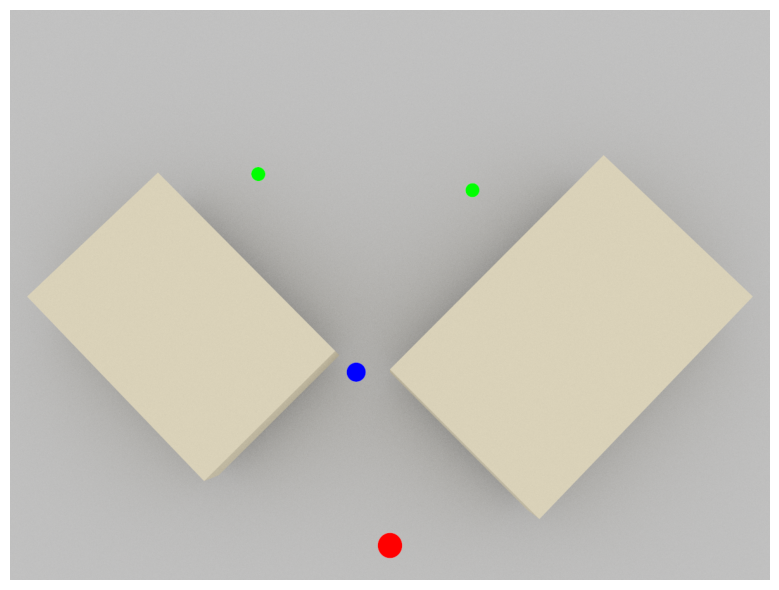

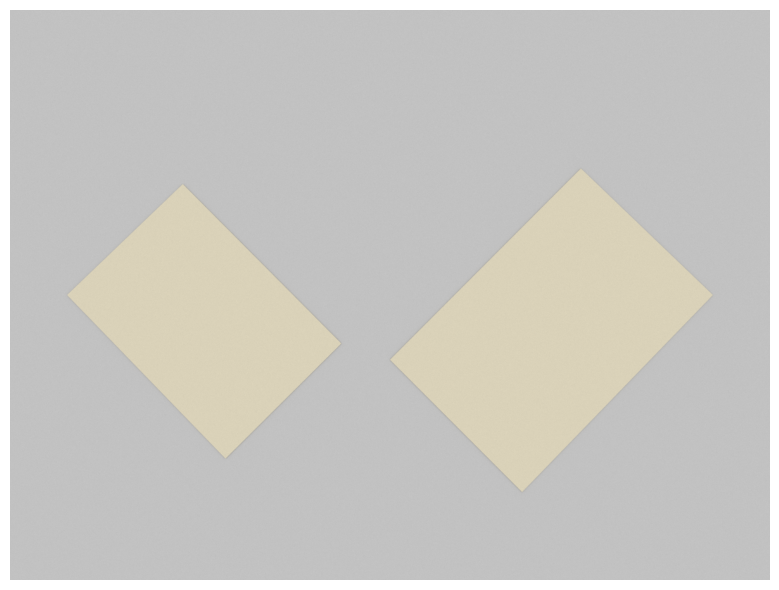

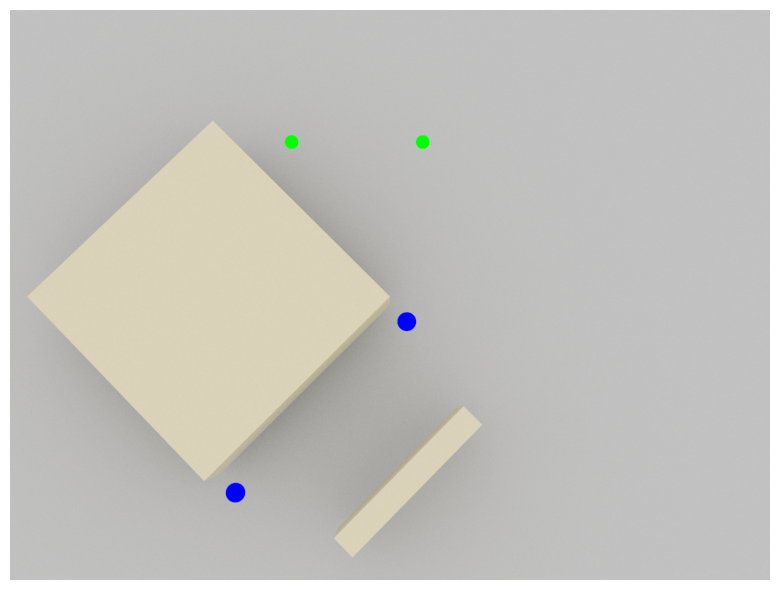

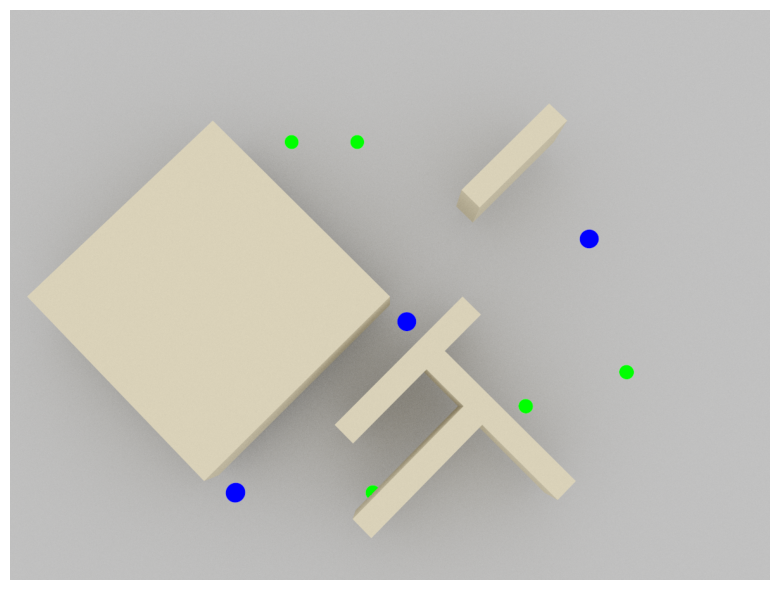

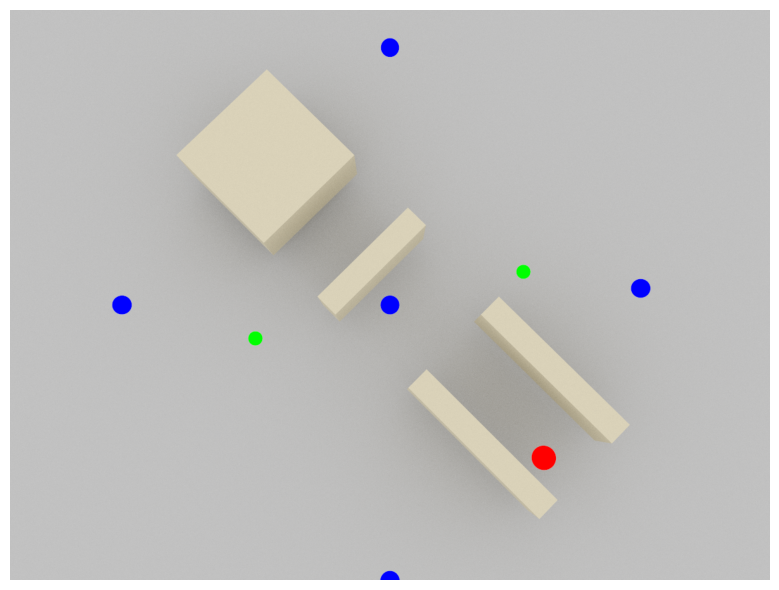

In [13]:
# Visualize all scenarios marked with calculate=True
should_do_all = True
if should_do_all:
    print("="*60)
    print("SCENARIO VISUALIZATION")
    print("="*60)

    scenarios_to_visualize = [s for s in situations if s['calculate']]
    print(f"\nFound {len(scenarios_to_visualize)} scenarios to visualize\n")

    for i, situation in enumerate(scenarios_to_visualize, 1):
        print(f"\n[{i}/{len(scenarios_to_visualize)}]")
        try:
            visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256)
            
        except Exception as e:
            print(f"❌ Error visualizing {situation['simulation_name']}: {e}")
            import traceback
            traceback.print_exc()

    print("\n" + "="*60)
    print("✓ All visualizations complete!")
    print("="*60)

## Visualize Individual Scenario

Use this cell to visualize a specific scenario by name with higher quality settings.


High-Quality Render (Single Reflection)

Single Reflection
Scene: 20m × 20m | Buildings: 2 | RIS: 1 | Receivers: 2

🔍 DEBUG: Starting path collection...
  TX point: {'x': 3, 'y': 3}
  RIS points (P1, P2, ...): [{'x': 7, 'y': 9}]
  Receivers (R1, R2, ...): [{'x': 16, 'y': 11}, {'x': 10, 'y': 18}]

📍 Collecting TX → P and TX → R paths...
  ✓ Including TX → P1
  ⊗ Skipping TX → R1 (building intersection)
  ⊗ Skipping TX → R2 (building intersection)

📍 Collecting P → P and P → R paths...
  ✓ Including P1 → R1
  ✓ Including P1 → R2

✅ Total paths to compute: 3
  • TX → P1
  • P1 → R1
  • P1 → R2

🔄 Grouping paths by source...
✅ Grouped into 2 source(s):
  • TX → 1 destination(s): ['P1']
  • P1 → 2 destination(s): ['R1', 'R2']

🔄 [1/2] Computing paths from TX...
  Source position: {'x': 3, 'y': 3}
  ✓ Added temp transmitter: temp_tx_TX
  ✓ Added temp receiver: temp_rx_P1 at {'x': 7, 'y': 9}
  🔄 Running PathSolver...
  ✅ PathSolver completed for TX
     Paths object type: <class 'sionna.rt.p

Traceback (most recent call last):
  File "/tmp/ipykernel_349695/2242460096.py", line 251, in visualize_scenario
    scene.render(
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/scene.py", line 626, in render
    image = render(
            ^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 173, in render
    overlay_scene = get_overlay_scene(
                    ^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/renderer.py", line 396, in get_overlay_scene
    starts, ends, colors = paths_to_segments(paths)
                           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/sionna/rt/utils/render.py", line 165, in paths_to_segments
    vertices = paths.vertices.numpy()
               ^^^^^^^^^^^^^^
AttributeError: 'list' object has no attribute 'vertices'


✓ Complete



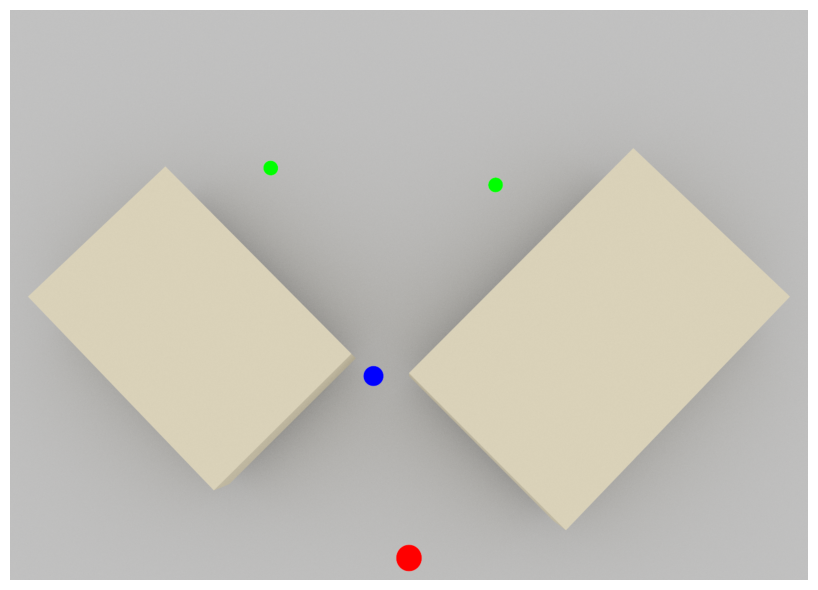

In [14]:
# Visualize a specific scenario by name
scenario_name = "Single Reflection"  # Change this to visualize different scenarios

situation = next((s for s in situations if s['simulation_name'] == scenario_name), None)

if situation:
    print(f"\nHigh-Quality Render ({scenario_name})")
    visualize_scenario(situation, render_resolution=(1400, 1000), num_samples=512)
else:
    print(f"Scenario '{scenario_name}' not found.")
    print("\nAvailable scenarios:")
    for s in situations:
        print(f"  - {s['simulation_name']}")

## Scene Information Summary

In [15]:
# Display summary table of all scenarios
summary_data = []
for situation in situations:
    summary_data.append({
        'Scenario': situation['simulation_name'],
        'Calculate': '✓' if situation['calculate'] else '✗',
        'Size (m)': f"{situation['width']}×{situation['height']}",
        'Resolution (m)': situation['resolution'],
        'Buildings': len(situation['buildings']),
        'RIS Points': len(situation['ris_points']),
        'Receivers': len(situation['receivers']),
    })

df = pd.DataFrame(summary_data)
print("\nScenario Summary:")
print("="*80)
display(df)


Scenario Summary:


,Scenario,Calculate,Size (m),Resolution (m),Buildings,RIS Points,Receivers
0,Single Reflection,✓,20×20,0.5,2,1,2
1,Single Reflection BIG,✓,2000×2000,50.0,2,1,2
2,Single Reflection - Clustered Receivers,✗,20×20,0.5,2,1,3
3,"RISs in series, only final",✓,20×20,0.5,2,2,2
4,RISs in series,✓,20×20,0.5,5,3,5
5,RISs in parallel,✓,20×20,0.5,4,5,3
